# Apply self-heating correction to open-path fluxes (NEE, 2004-2019)

# Imports

In [1]:
from datetime import datetime
from pathlib import Path
import pandas as pd
from diive.core.io.files import save_parquet, load_parquet
from diive.pkgs.flux.selfheating import ScopPhysics, ScopOptimizer, ScopApplicator

# Docstring

In [2]:
help(ScopApplicator)

Help on class ScopApplicator in module diive.pkgs.flux.selfheating:

class ScopApplicator(builtins.object)
 |  ScopApplicator(flux_type: Literal['CO2', 'H2O'], fct_unsc: pandas.core.series.Series, scaling_factors_df: pandas.core.frame.DataFrame, flux_openpath: pandas.core.series.Series, classvar: pandas.core.series.Series, daytime: pandas.core.series.Series, latent_heat_vaporization: Optional[pandas.core.series.Series] = None)
 |  
 |  Methods defined here:
 |  
 |  __init__(self, flux_type: Literal['CO2', 'H2O'], fct_unsc: pandas.core.series.Series, scaling_factors_df: pandas.core.frame.DataFrame, flux_openpath: pandas.core.series.Series, classvar: pandas.core.series.Series, daytime: pandas.core.series.Series, latent_heat_vaporization: Optional[pandas.core.series.Series] = None)
 |      Args:
 |          flux_type: "CO2" or "H2O"
 |          latent_heat_vaporization: Series of Lambda (J/mmol or J/kg depending on inputs).
 |                                    Required ONLY if flux_type

# Load data

In [3]:
SOURCEDIR = r"../../20_MERGE_DATA"
FILENAME = r"21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")
df = load_parquet(filepath=FILEPATH)
df

Data will be loaded from the following file:
..\..\20_MERGE_DATA\21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet
Loaded .parquet file ..\..\20_MERGE_DATA\21.4_FLUXES_L1_noSHC_IRGA75+METEO7.parquet (0.500 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,...,W_T_SONIC_COV_IBROM_N1626,W_UNROT,W_U_COV,W_VM97_TEST,W_ZCD,ZL,ZL_UNCORR
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,
2004-03-30 14:45:00,1005.41,1.12844,0.025668,1134.55,0.0,1.0,37.0,...,0.429576,-0.227060,-0.209191,800000001.0,14.0,-1.260300,-1.311810
2004-03-30 15:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-03-30 15:45:00,1005.42,1.12663,0.025709,1132.74,0.0,1.0,37.0,...,0.208402,-0.063026,0.002830,800000001.0,39.0,-0.350351,-0.361224
2004-03-30 16:15:00,1005.43,1.12587,0.025726,1131.98,0.0,1.0,37.0,...,0.130654,-0.028456,-0.034904,800000000.0,76.0,-0.295734,-0.304238
2004-03-30 16:45:00,1005.44,1.12521,0.025742,1131.33,0.0,1.0,37.0,...,0.090910,0.371090,-0.012976,800000000.0,247.0,-0.702368,-0.729167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-12-31 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-12-31 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Calculate unscaled flux correction term with `ScopPhysics`

In [4]:
physics = ScopPhysics(
    flux_type="CO2",
    ta=df["TA_T1_47_1"].copy(),
    gas_density=df["CO2_MOLAR_DENSITY"].copy() * 1000,  # Requires umol m-3
    rho_a=df["AIR_DENSITY"].copy(),
    rho_v=df["VAPOR_DENSITY"].copy(),
    u=df["U"].copy(),
    c_p=df["AIR_CP"].copy(),
    ustar=df["USTAR"].copy(),
    swin=df["SW_IN_T1_47_1_gfXG"].copy(),
    lat=47.478333,  # CH–LAE
    lon=8.364389,  # CH–LAE
    utc_offset=1,
)
physics.run(correction_method_base="JAR09", gapfill=True)
results_physics_df = physics.get_results()

Aerodynamic resistance: Mean = 25.97 s m-1
Dry air density: Mean = 1.1440 kg m-3


Starting gap-filling for
FCT_UNSC
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1', 'AIR_CP', 'AIR_DENSITY', 'U', 'USTAR'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['FCT_UNSC']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 185327.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestamp TIMESTAMP_MIDDLE to datetime ... OK
>

In [5]:
results_physics_df.describe()

,FCT_UNSC_gfRF,FCT_UNSC,TS,TA_T1_47_1,AIR_CP,AERODYNAMIC_RESISTANCE,AIR_DENSITY,...,U,USTAR,CO2_MOLAR_DENSITY,SW_IN_T1_47_1_gfXG,AIR_THERMAL_CONDUCTIVITY,DAYTIME,LATENT_HEAT_VAPORIZATION_J_UMOL
count,254117.000000,185327.000000,265180.000000,265180.000000,237184.000000,215087.000000,237184.000000,...,237184.000000,237184.000000,219670.000000,267867.000000,265180.000000,267867.000000,265180.000000
mean,15.191615,15.527694,10.524726,8.420737,1010.532462,13.104677,1.150846,...,2.487897,0.488472,15897.744208,142.184275,0.024839,0.444855,0.044697
std,11.277377,12.361281,8.226763,8.197828,2.567790,11.109658,0.034960,...,1.802394,0.305275,2342.644800,235.135052,0.000574,0.496951,0.000350
min,0.872043,0.872043,-16.540001,-17.200001,971.364000,0.031634,1.053700,...,0.009557,0.007408,7997.360000,0.000000,0.023046,0.000000,0.043628
25%,7.283693,6.428616,4.153088,2.050000,1008.550000,5.548491,1.124640,...,1.159165,0.252583,14670.000000,0.000000,0.024393,0.000000,0.044440
50%,12.216007,12.079792,10.675100,8.443055,1010.150000,9.284189,1.148710,...,2.051880,0.432681,15479.900000,0.000000,0.024841,0.000000,0.044696
75%,19.680983,20.877839,16.645700,14.440464,1012.310000,16.787022,1.176350,...,3.358270,0.658532,16398.975000,194.364494,0.025261,1.000000,0.044969
max,103.919409,103.919409,34.840751,33.445910,1021.520000,85.902511,1.278340,...,13.249100,3.322560,37033.300000,1110.706662,0.026591,1.000000,0.045791


Plotting Physics Diel Cycles...


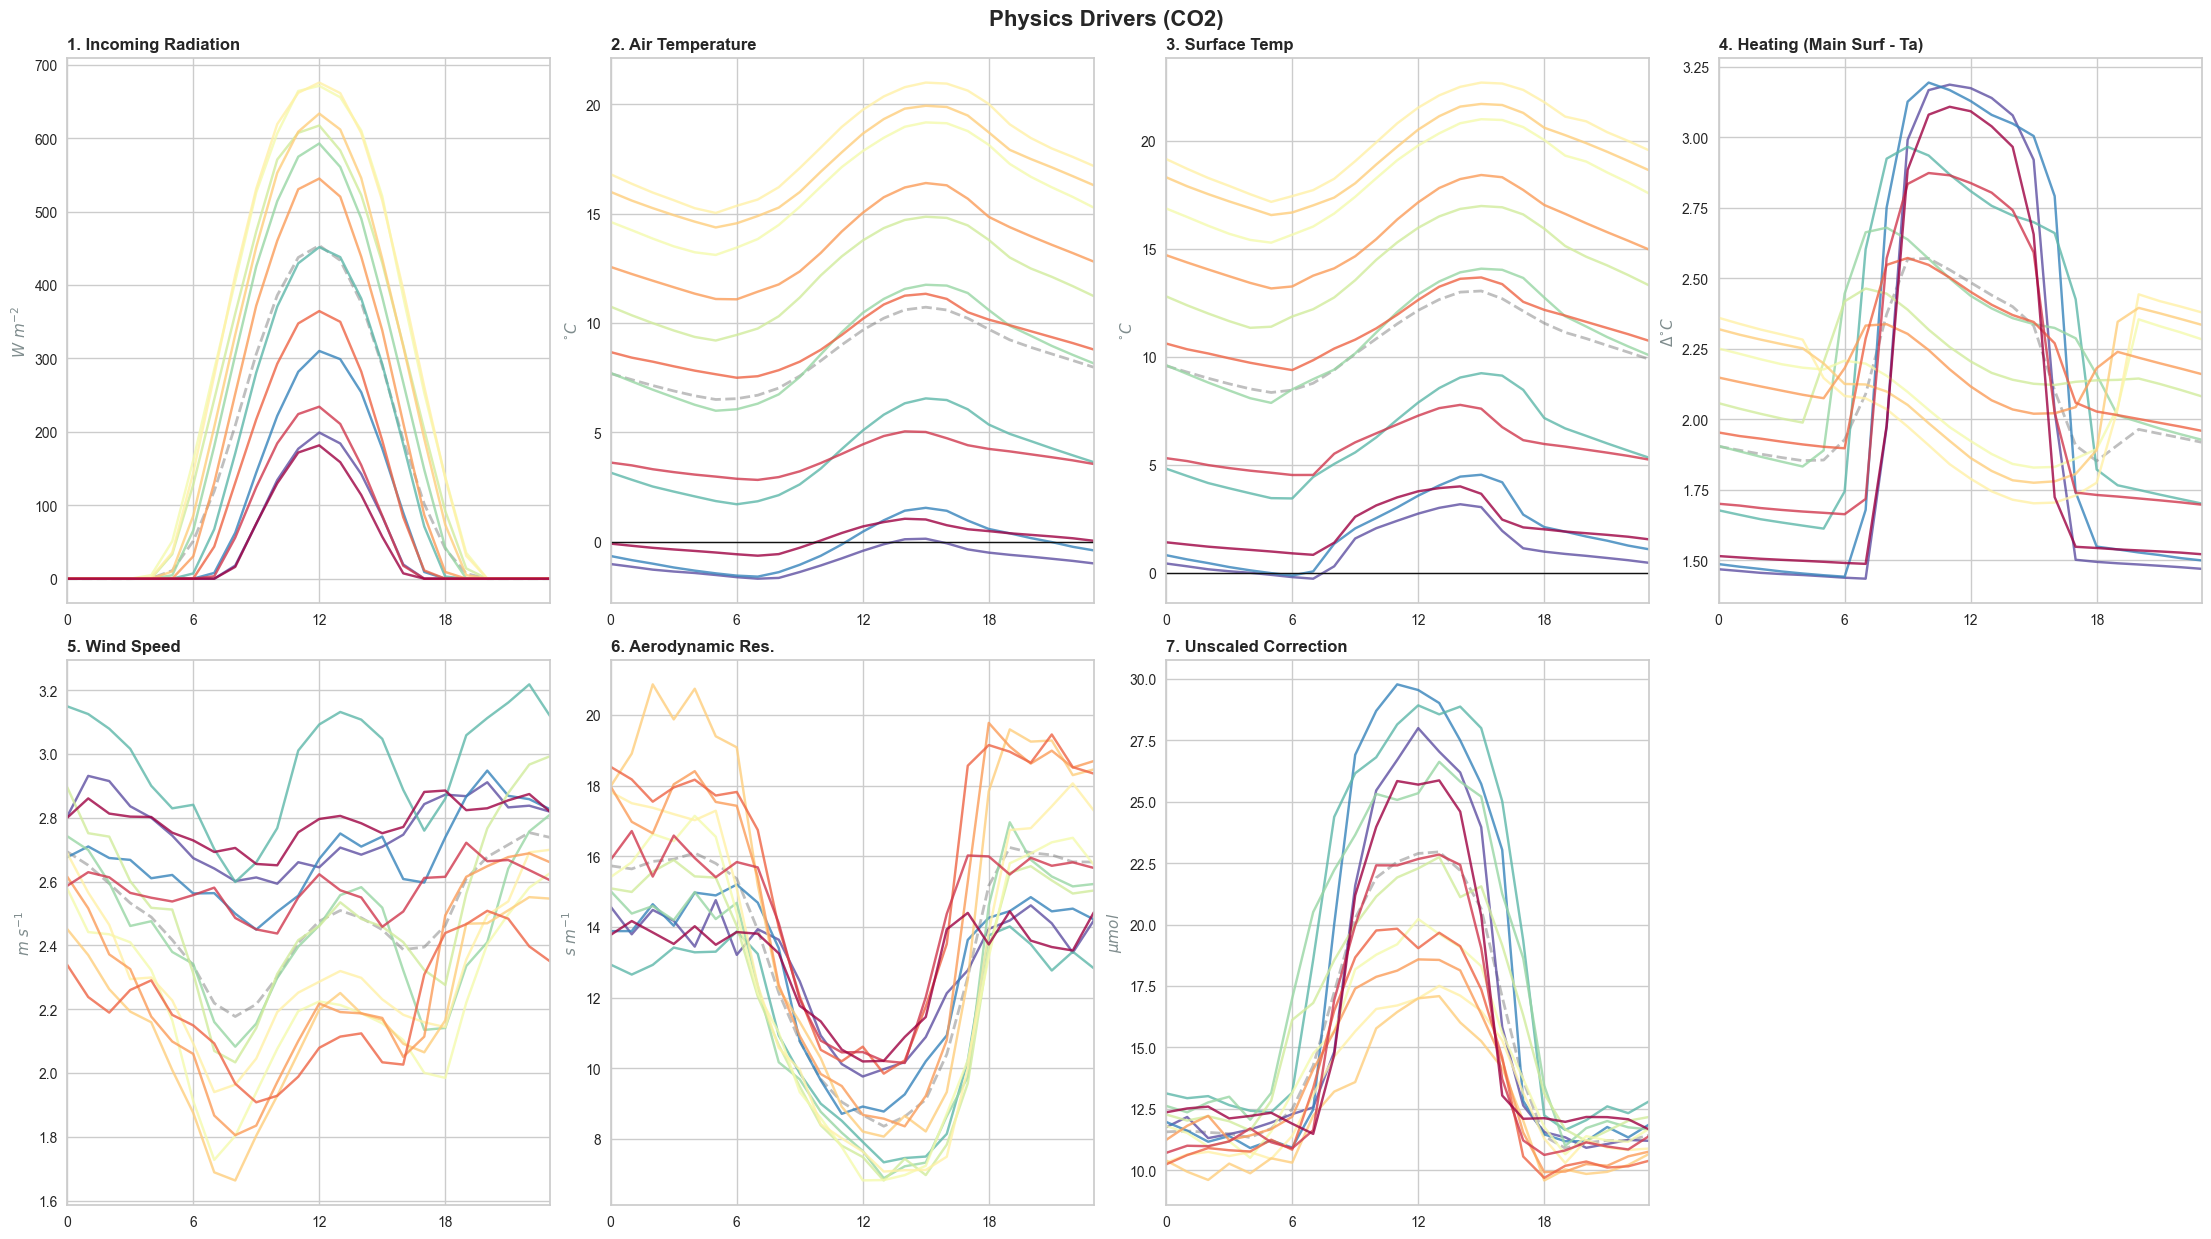

In [6]:
physics.plot_diel_cycles()

# Load scaling factors from `ScopOptimizer`

In [7]:
sfdf = pd.read_csv("32_SelfHeatingCorrection_ScalingFactors_NEE.csv")
sfdf

,Unnamed: 0,DAYTIME,GROUP_CLASSVAR,GROUP_CLASSVAR_MIN,GROUP_CLASSVAR_MAX,BOOTSTRAP_RUNS,SF_MEDIAN,SF_Q25,SF_Q75,SF_Q01,SF_Q99,SOS_MEDIAN,NUMVALS_AVG
0,0,0.0,0.0,0.027716,0.092605,100,0.056168,0.044564,0.062324,0.013046,0.078278,42.326613,36
1,1,0.0,1.0,0.094653,0.119879,100,0.238439,0.059487,0.286189,0.031037,0.476701,332.129436,32
2,2,0.0,2.0,0.122276,0.144957,100,0.309048,0.218443,0.418357,0.080136,0.591644,384.737771,38
3,3,0.0,3.0,0.146694,0.167737,100,0.125893,0.096872,0.157369,0.051833,0.257225,102.041515,39
4,4,0.0,4.0,0.169055,0.192914,100,0.389207,0.221277,0.595500,0.074262,1.025125,591.698067,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,35,1.0,15.0,0.673636,0.724010,100,0.123569,0.116967,0.130817,0.102837,0.143177,7732.748842,426
36,36,1.0,16.0,0.724078,0.787927,100,0.134933,0.127008,0.139943,0.116712,0.162122,8345.965774,400
37,37,1.0,17.0,0.788481,0.872671,100,0.120378,0.116947,0.123693,0.108560,0.131513,5018.795664,392
38,38,1.0,18.0,0.873211,1.004330,100,0.094032,0.088718,0.100579,0.071700,0.110144,6959.287489,382


# Correct open-path fluxes with `ScopApplicator`

In [8]:
applicator = ScopApplicator(
    flux_type="CO2",
    fct_unsc=results_physics_df["FCT_UNSC_gfRF"],
    scaling_factors_df=sfdf,
    flux_openpath=df["FC"].copy(),
    classvar=df["USTAR"].copy(),
    daytime=results_physics_df["DAYTIME"].copy()
)
applicator.run()

(!) Warning: 7647 fluxes missing Scaling Factor (due to missing USTAR).
    Imputing using Month-Daytime-Hour Diel Cycle Median...
    (!) 7647 items still NaN (Specific Month-Hour combination has no data).
    -> Filling these edge cases with the global Month-Daytime median.
    > Successfully imputed 0 missing Scaling Factors.


In [9]:
applicator.stats()



                          FLUX CORRECTION REPORT                           
Flux Type      : CO2
Total Records  : 219,562
---------------------------------------------------------------------------
1. SCALING FACTOR ASSIGNMENT                                  (Method Used)
...........................................................................
   Direct Lookup (Valid USTAR) :  219,562  (100.0%)
 i Gap-Filled    (MDV Imputation) :        0  (  0.0%)

   Median Scaling Factor (Day)     : 0.188
   Median Scaling Factor (Night)   : 0.108


2. CORRECTION IMPACT (Budget)                                  (Units: Sum)
...........................................................................
   Uncorrected Sum                 :        -744,016
   Corrected Sum                   :        -248,559
   Net Adjustment                  :         495,457  (+66.6%)




Generating Comprehensive Flux Dashboard (Large Font Edition)...


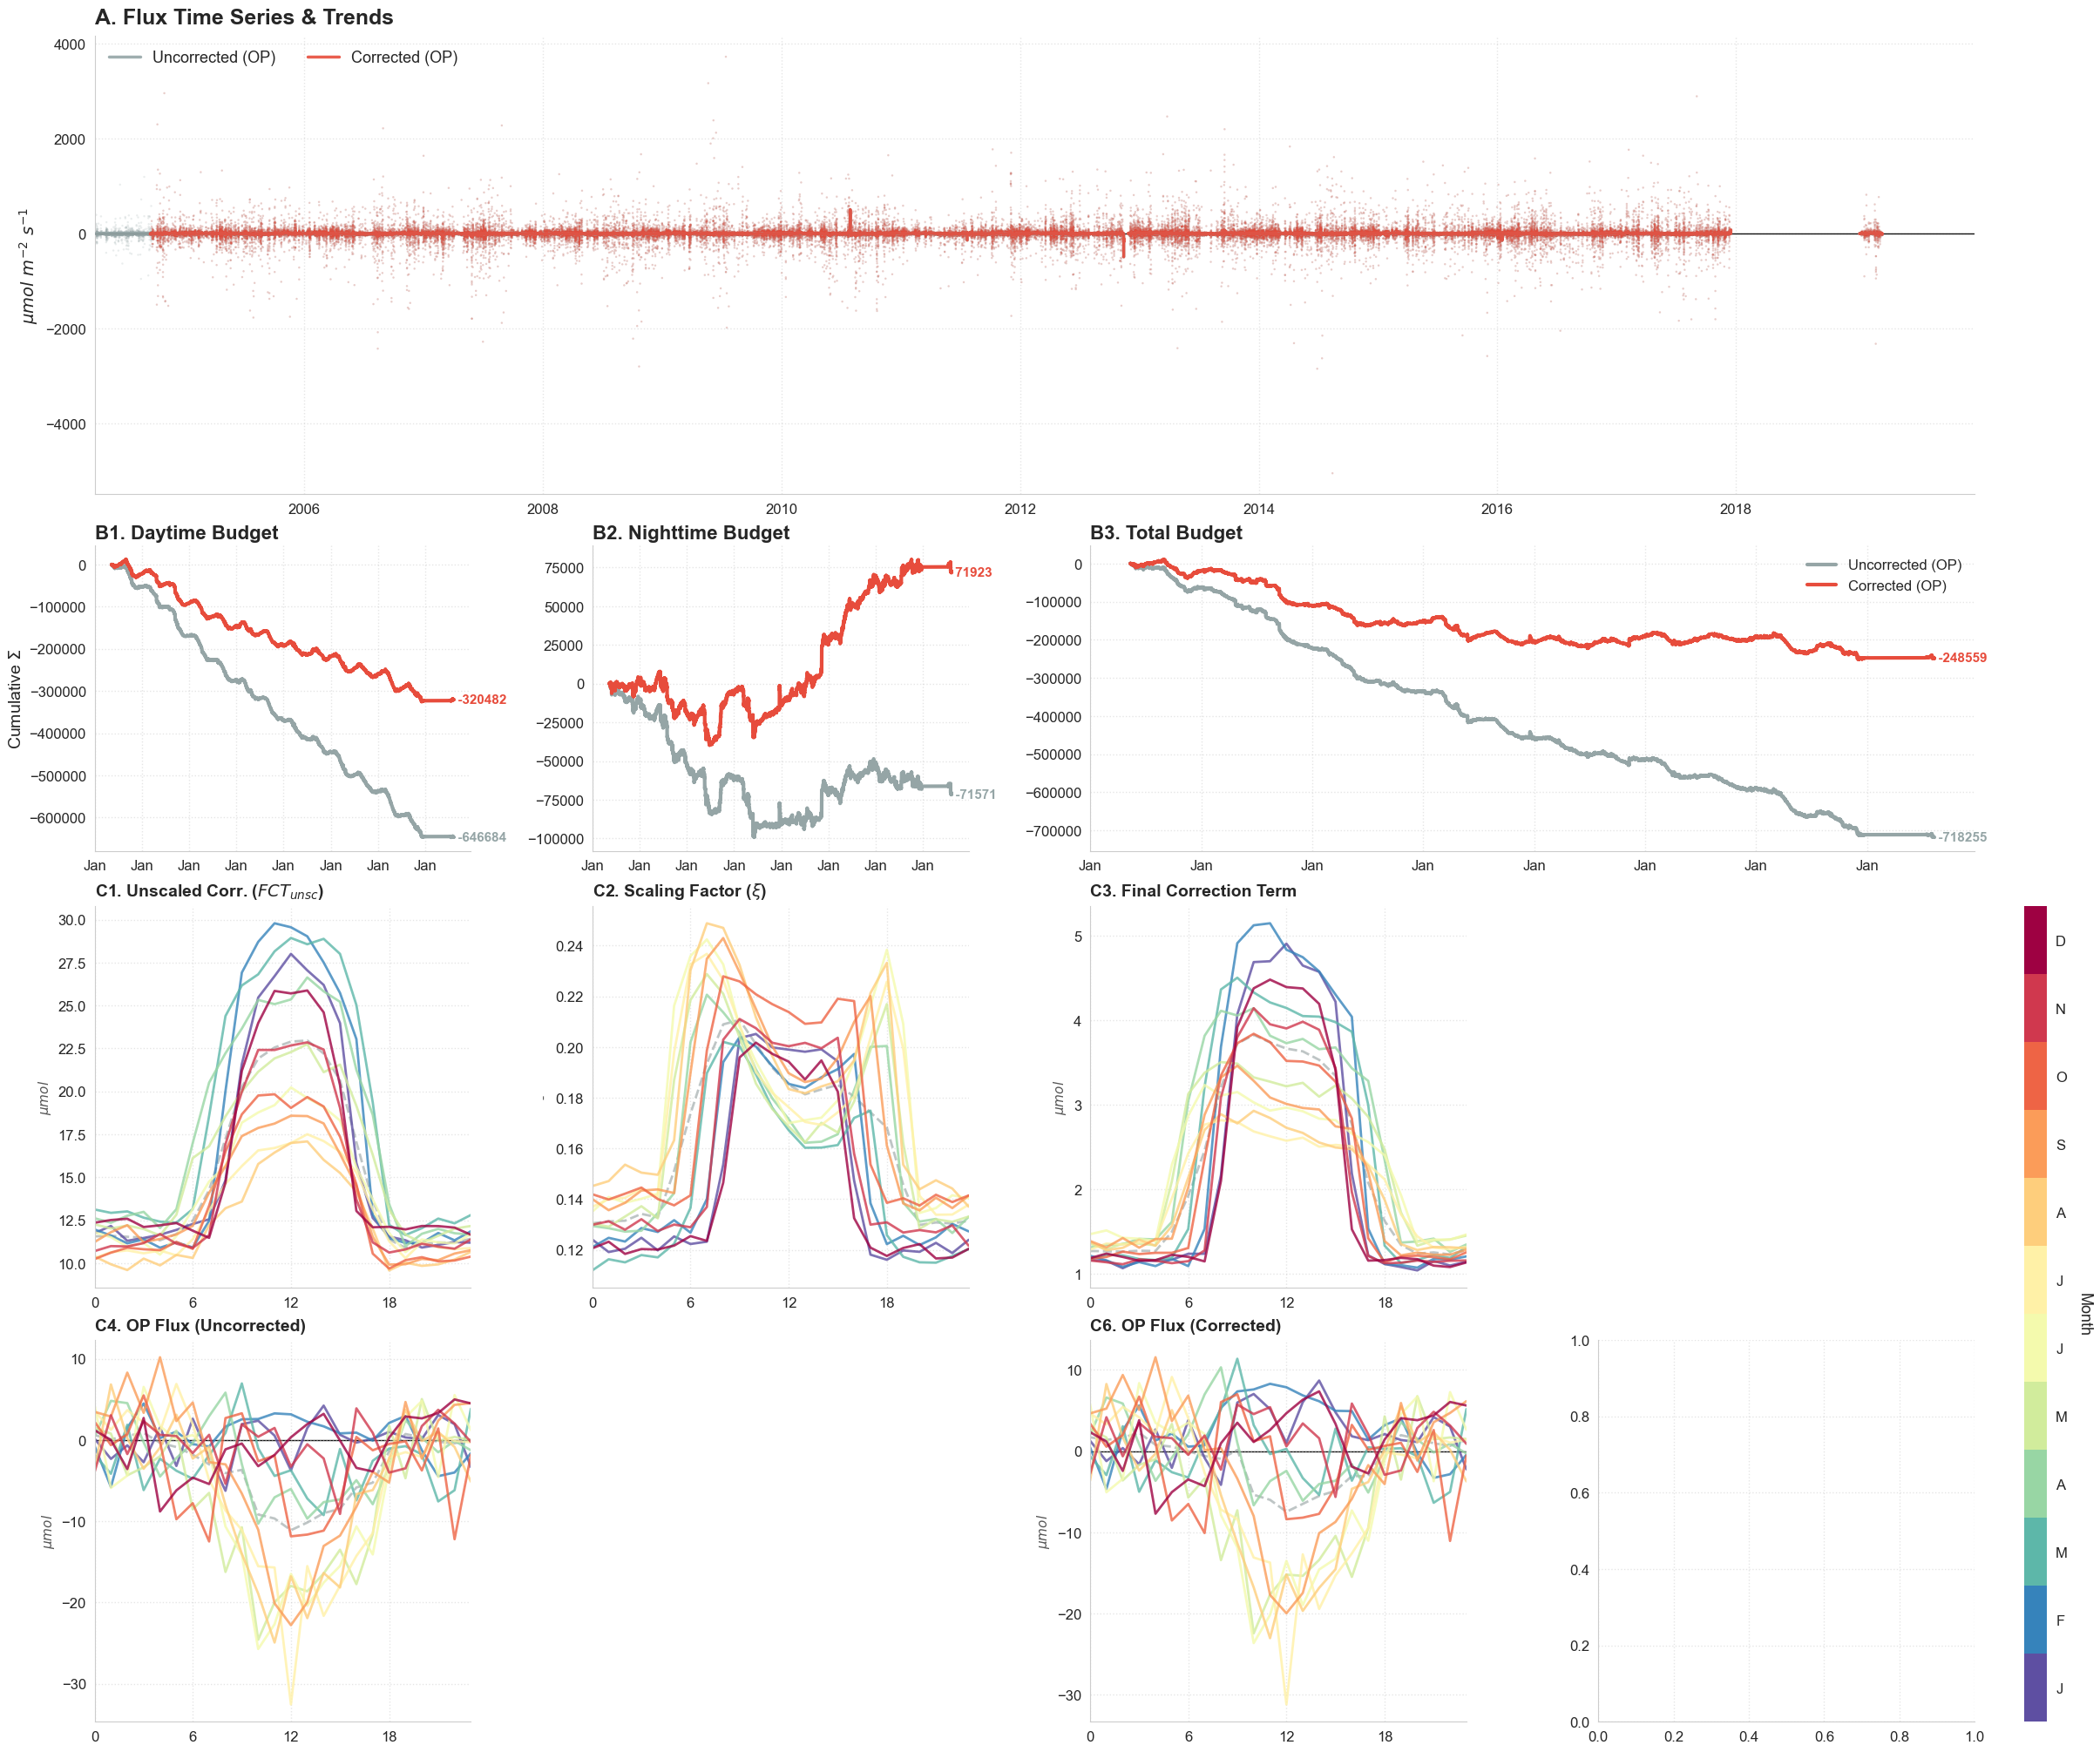

In [10]:
applicator.plot_dashboard();

# Save to file

In [11]:
filename = "42_XXX"
df.to_csv(f"{filename}.csv", index=True)

# ✅END OF NOTEBOOK

In [12]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-11-29 02:28:25
